# Alluvial Diagrams

DS 2023 | Communicating with Data

<!-- <img src="https://virginia.box.com/shared/static/5ykx63njw8amir6c1u62r19gqwx8xm57.png" width="650"/> -->

<img src="https://virginia.box.com/shared/static/iixwxz7rhjq5n8d8bhvvwn0r1ultbzi2.png"/>

## Overview

An **alluvial diagram** shows how the observations in a dataset split and combine across a series of categorical variables.

Each **categorical variable** gets its own vertical **axis**.

Each **category value** on an axis is shown as a block, called a **stratum**, with height proportional to its count.

Bands called **flows** or **ribbons** connect the strata on neighboring axes.

The **width of a flow** stands for the number of observations that share both categories.

**Every observation travels through every axis**, so the total height of each axis is the same.

> [!NOTE]
>
> The name comes from [Rosvall and Bergstrom (2010)](https://arxiv.org/abs/0812.1242), who used these diagrams to show how scientific fields merged and split over time, like sediment in a river delta.
>
> The word **alluvial** comes from the **alluvium**, a Medieval Latin noun meaning "matter deposited by flowing water," itself deriving from Latin **alluere**, "to wash against."
>
> The general idea itself goes back to Matthew Sankey, who drew energy flowing through a steam engine in 1898, and Bendix, Kosara and Hauser introduced **parallel sets** for categorical data in 2005.

## Use Cases

**Cross-classification:** how one population splits along several categories at once, e.g. who survived the Titanic, by class and sex.

**Contingency tables:** making a multi-way table of counts visible, e.g. admissions to a university by department and gender.

**Repeated measures:** the same subjects observed at several times, e.g. students changing majors from semester to semester.

## Creating an alluvial diagram from scratch

Think of an alluvial diagram as something like **a connected set of stacked bar charts**.

Let's create the bars and show how they are connected into an alluvial.

We will use the `titanic` dataset and `class`, `sex`, and `alive` as our group variables.

To prepare the data, we will first convert the group variables to **categorical** data types.

In [486]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic_group_cols = ['class', 'sex', 'alive']
titanic[titanic_group_cols] = titanic[titanic_group_cols].astype('category')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Since we want to compare three columns &mdash; `class`, `sex`, and `alive` &mdash;  we use `value_counts` to get the number of observations for each combination.

This tells us how much data "flows" from one variable to another.

For example, we can see that $336$ observations (people) flow from being `class = 'Third'` and `sex = 'male'` to not surviving (`alive = 'no'`).

```{note}
Here we get a normalized value count, so that the flows represent relative frequencies and not raw values. 

We also convert the values in $[0,1]$ so they are easier to plot.
```

In [487]:
flows = titanic.value_counts(titanic_group_cols, normalize=True).to_frame('n').reset_index()
flows['n'] = (flows['n'] * 1000).astype(int)
flows

,class,sex,alive,n
0,Third,male,no,336
1,First,female,yes,102
2,Second,male,no,102
3,First,male,no,86
4,Third,female,no,80
5,Third,female,yes,80
6,Second,female,yes,78
7,Third,male,yes,52
8,First,male,yes,50
9,Second,male,yes,19


**Pick a key column**

Before we construct the vertical axes and their strata, we need to pick a grouping variable.

This variable that will be used to color the ribbons.

In [488]:
# key_col = 'alive'
key_col = 'class'
# key_col = 'sex'

**Create the vertical axes and strata**

Next, we compute the strata for each vertical axis.

These can be acquired by **sorting the columns** by the axis variable, followed by the other variables, and then computing the cumulative sums.

We also add a little gap between each category for each variable.

In [489]:
gap = 10
for i, col in enumerate(titanic_group_cols):
    sort_cols = titanic_group_cols.copy()
    sort_cols.insert(0, sort_cols.pop(i)) # Pull out the current col and put it first
    print(i, col, sort_cols, sep="\t")
    flows[f'{col}_y'] = flows.sort_values(sort_cols).n.cumsum() + flows[col].cat.codes * gap
flows

0	class	['class', 'sex', 'alive']
1	sex	['sex', 'class', 'alive']
2	alive	['alive', 'class', 'sex']


,class,sex,alive,n,class_y,sex_y,alive_y
0,Third,male,no,336,962,952,613
1,First,female,yes,102,105,105,725
2,Second,male,no,102,437,597,197
3,First,male,no,86,191,445,89
4,Third,female,no,80,546,269,277
5,Third,female,yes,80,626,349,952
6,Second,female,yes,78,335,189,853
7,Third,male,yes,52,1014,1004,1004
8,First,male,yes,50,241,495,775
9,Second,male,yes,19,456,616,872


You can see how the cumulative sums and gaps will be used to construct the vertical axes and strata.

In the stacked bar chart below, each column shows the same data, just grouped and sorted differently.

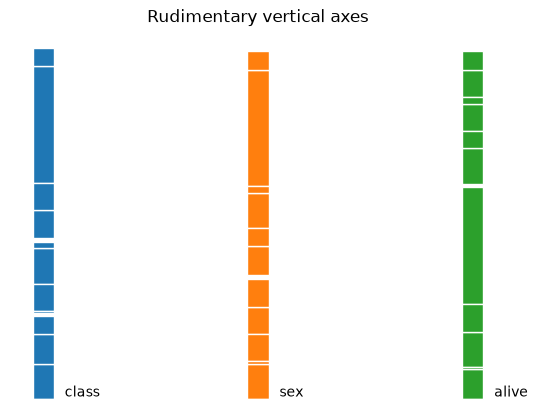

In [490]:
for i, col in enumerate(titanic_group_cols):
    plt.bar(i, flows.n, bottom=flows[f'{col}_y'] - flows.n, edgecolor='white', width=.1)
    plt.text(i + .1, 10, col)
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.title("Rudimentary vertical axes")
plt.show()

**Plot the diagram**

Now, we plot the vertical axes, strata, and ribbons.

First, we'll pick a suitable colormap to color the strata and ribbons.

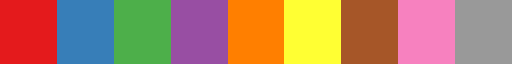

In [491]:
palette = 'Set1'
cmap = plt.colormaps.get_cmap(palette)
cmap

Then we get the category object for our `key_col` so we can grab the category code for the value of the `key_col` at runtime.

In [492]:
key_cats = flows[key_col].cat.categories
key_cats

Index(['First', 'Second', 'Third'], dtype='str')

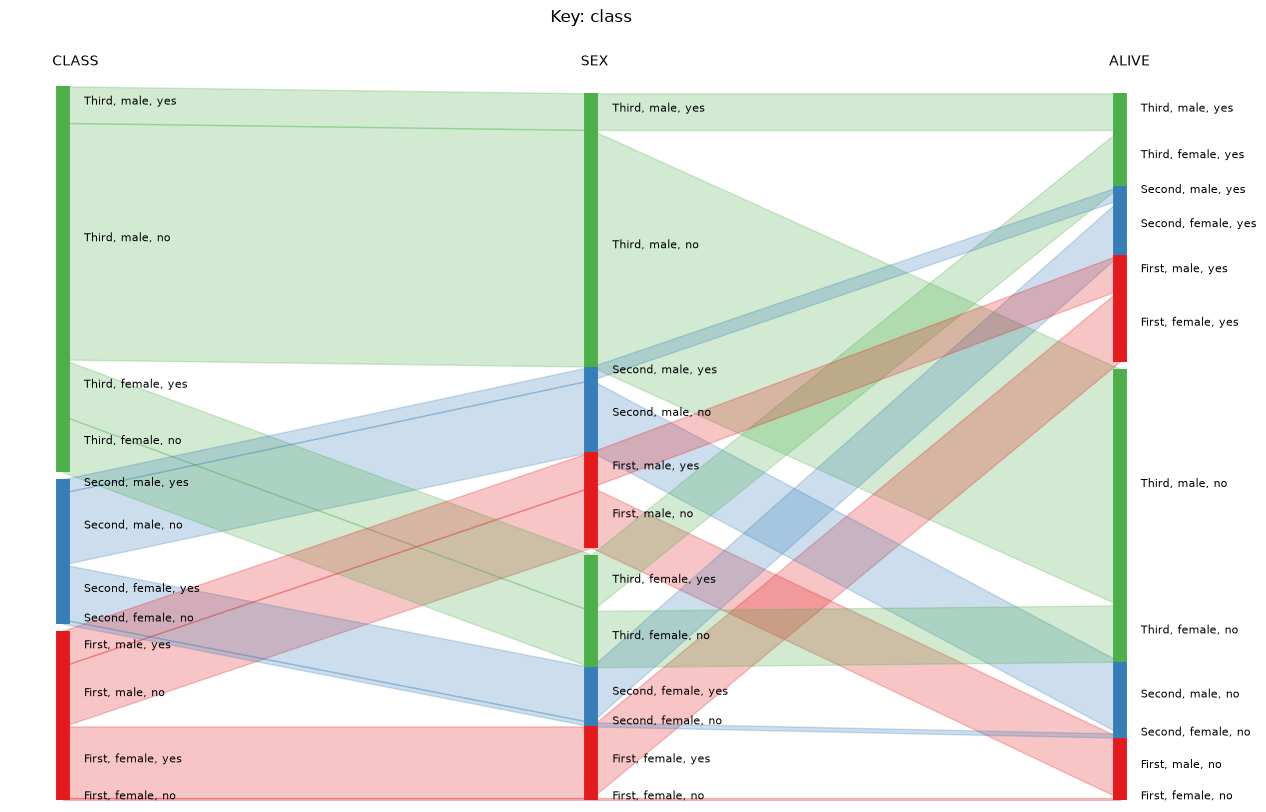

In [493]:
plt.figure(figsize=(15,10))

for idx, row in flows.iterrows():

    # Get the height of the stratum
    n = row['n']

    # Get the color for this row
    key_col_val = row[key_col]
    key_col_code = key_cats.get_loc(key_col_val)
    color = cmap(key_col_code)

    # Plot the markers
    for i, col in enumerate(titanic_group_cols):

        # Get the x axis offset of the grouping col, starting with 1
        x = i + 1

        # Get the y value, i.e. the cumulative value
        y = row[f'{col}_y']

        # Plot the bars
        plt.plot([x, x], [y - n, y], lw=10, color=color, solid_capstyle='butt')

        # Add a label using plt.text(x, y, text)
        plt.text(x + .04, y - n/2, ", ".join(row[titanic_group_cols].values), fontsize=8)

    # Plot the ribbons using fill_between
    x_vals = [i+1 for i in range(len(titanic_group_cols))]                        # Again, get the x axis offsets 
    y_vals = row[[f"{col}_y" for col in titanic_group_cols]].values.astype(float) # Get the pair of y values
    plt.fill_between(x_vals, y_vals, y_vals - n, alpha=.25, color=color)

# Add labels to each vertical axis
N = flows.n.sum()
for i, col in enumerate(titanic_group_cols):
    plt.text(i+1 - .02, N + N * .05, col.upper())

# Title
plt.title(f"Key: {key_col}")

# Clean up
plt.ylim(0, N + N * .1)
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])

plt.show()

Notice how much of the Third-class stratum flows into `no`.

## Using Plotly

Now let's use Plotly to create an alluvial diagram from the same data.

It does a much better job of it, but the logic behind the diagram is the same.

In [494]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

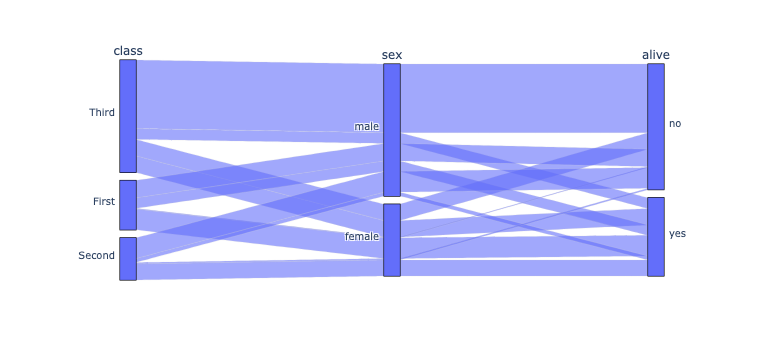

In [495]:
px.parallel_categories(titanic[titanic_group_cols])

We can see the three axes and the flows between them.

Note that the plot is **interactive**:

- Hovering over an element reveals information about it.

- You can also drag a stratum up or down to reorder it.

**Coloring by a variable**

Let's color the flows by whether the passenger survived.

Let's also set `line_shape='hspline'` to curve the flows, which makes them easier to follow.

We'll use the same palette we use above, this time from Plotly's `colors` module.

In [496]:
plotly_cmap = px.colors.qualitative.Set1
plotly_cmap

['rgb(228,26,28)',
 'rgb(55,126,184)',
 'rgb(77,175,74)',
 'rgb(152,78,163)',
 'rgb(255,127,0)',
 'rgb(255,255,51)',
 'rgb(166,86,40)',
 'rgb(247,129,191)',
 'rgb(153,153,153)']

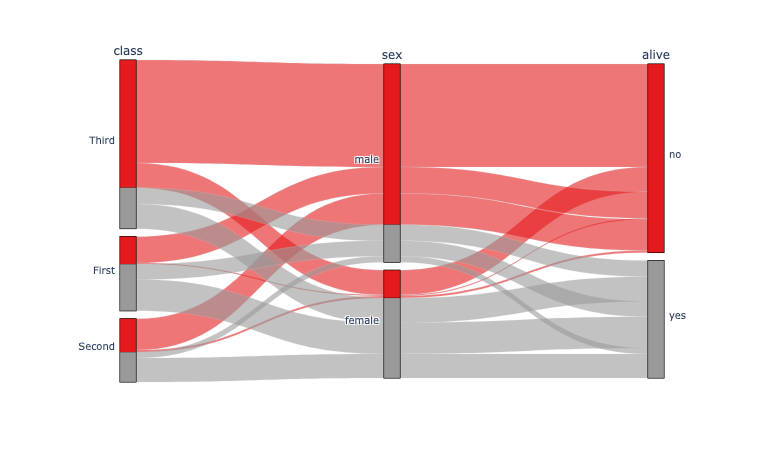

In [497]:
fig = px.parallel_categories(
    titanic,
    dimensions=['class','sex','alive'], 
    color=titanic['alive'].cat.codes,
    color_continuous_scale=plotly_cmap,
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

From this diagram we can see that most first-class passengers survived, and most third-class passengers did not.

But we also notice that about two thirds of the survivors were women, and most of the men did not survive.

:::{note}

The two colors used in the plot &mdash; red and gray &mdash; come from the **first** and **last** colors in the palette we chose ({eval}`palette`), reflecting how Plotly picks colors based on the numbers you give it.

{eval}`cmap`

If we wanted to use the first two colors in the palette &mdash; red and blue &mdash; we could use this argument: 

```python
color_continuous_scale = plotly_cmap[:len(titanic['alive'].unique())]
```
Here we take a slice of the list of colors using the length of the variable domain.

We'll use this pattern going forward.

:::

## Tidy data

Most tidy tables can be visualized using alluvials, as long as you want to visualize the categorical (or binnable) variables.

The fact that each row is an observation means that **individual entities can be traced across the ribbons** connecting the vertical axes. 

Let's demonstrate this with some familiar datasets.

### Penguins

Let's look at how the grouping variables of the Penguins dataset are related.

```{note}
In this table, and going forward, we convert all grouping variables to **categories**.

This is because Plotly wants to use numbers when assigning colors.
```

In [498]:
penguins = sns.load_dataset('penguins').dropna()
penguins_group_cols = ['species', 'sex', 'island']
penguins[penguins_group_cols] = penguins[penguins_group_cols].astype('category')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


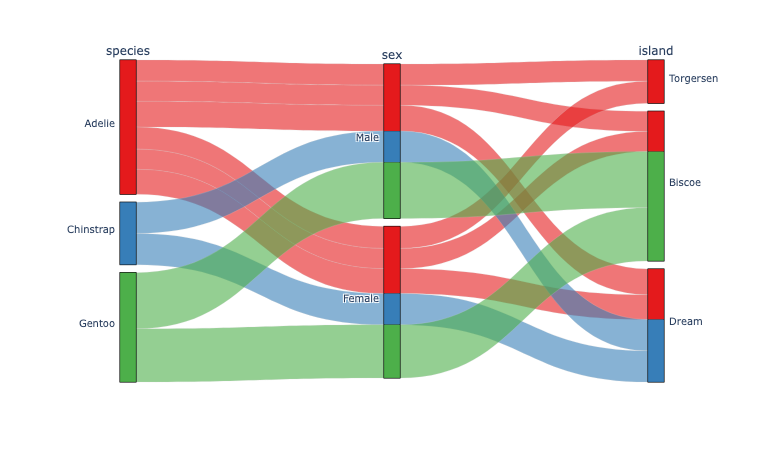

In [499]:
fig = px.parallel_categories(
    penguins,
    dimensions=penguins_group_cols,
    color=penguins.species.cat.codes,
    color_continuous_scale=plotly_cmap[:len(penguins['species'].unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Notice the flows that are _missing_.

- Gentoo live **only** on Biscoe, and Chinstrap only on Dream.

- Adelie are the only species found on all three islands.

**An alluvial diagram shows the absence of a combination as clearly as its presence.**

Notice also that sex doesn't matter much in the diagram since the data are balanced over that variable.

### Cars

Numeric measurement variables can be axes too, as long as they have only a few distinct values. 

Here `cylinders` has five values, and we bin `model_year` into three periods.

In [500]:
mpg = sns.load_dataset('mpg')

# Create a smaller grouping variable
mpg['period'] = pd.cut(
    mpg['model_year'], 
    bins=[69, 73, 77, 82],
    labels=['1970–73', '1974–77', '1978–82']
)

mpg_group_cols = ['origin', 'cylinders', 'period']
mpg[mpg_group_cols] = mpg[mgg_group_cols].astype('category')
mpg[mpg_group_cols]

,origin,cylinders,period
0,usa,8,1970–73
1,usa,8,1970–73
2,usa,8,1970–73
3,usa,8,1970–73
4,usa,8,1970–73
...,...,...,...
393,usa,4,1978–82
394,europe,4,1978–82
395,usa,4,1978–82
396,usa,4,1978–82


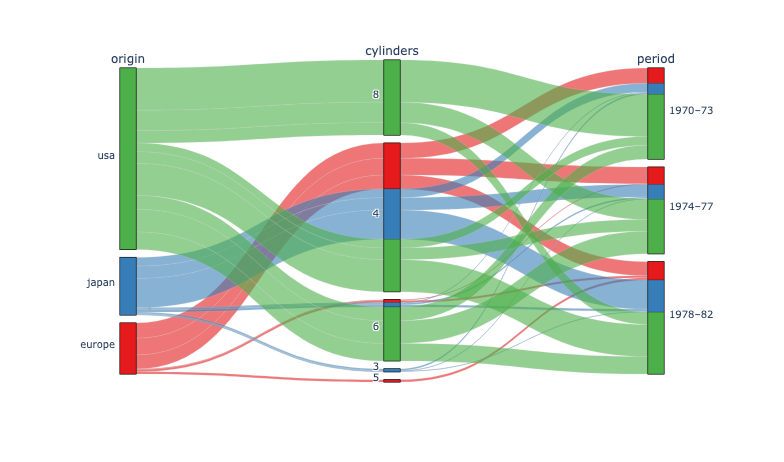

In [501]:
fig = px.parallel_categories(
    mpg,
    dimensions=['origin', 'cylinders', 'period'],
    color=mpg['origin'].cat.codes,
    color_continuous_scale=plotly_cmap[:len(mpg['origin'].unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Nearly every eight-cylinder car is American.

Follow the `8` stratum into the last period and notice how much thinner it gets after the oil crises.

## Aggregated data

Many datasets come already counted: instead of one row per observation, they have one row per combination, with a frequency column showing how many observations have this combination.

For this kind of table to work with `parallel_categories`, we need to exand it, so that each observation is represented as a row.

For example, if data looks like this:

```csv
A,B,C,5
A,D,Q,2
```

It would need to be converted to this:

```csv
A,B,C
A,B,C
A,B,C
A,B,C
A,B,C
A,D,Q
A,D,Q
```

One way to achieve this effect in Pandas is by using `df.index.repeat(freq_col)`.

### College admissions

Here is some data about college admissions to Cal Berkeley from $1973$.

In [502]:
ucb_data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/UCBAdmissions.csv"
ucb = pd.read_csv(ucb_data_url).drop('rownames', axis=1)
ucb.head()

,Admit,Gender,Dept,Freq
0,Admitted,Male,A,512
1,Rejected,Male,A,313
2,Admitted,Female,A,89
3,Rejected,Female,A,19
4,Admitted,Male,B,353


First, we convert the grouping variables to categories.

In [528]:
ucb_group_cols = ['Admit','Gender', 'Dept']
ucb[ucb_group_cols] = ucb[ucb_group_cols].astype('category')

Next, we expand the table so that it has as many rows as there were people in the original pre-aggregated dataset.

In [529]:
ucb_people = (
    ucb.loc[ucb.index.repeat(ucb['Freq'])] # Expand the dataframe
    .reset_index(drop=True)                # Replace the index
    .drop('Freq', axis=1)                  # Drop the Freq column
)
ucb_people

,Admit,Gender,Dept
0,Admitted,Male,A
1,Admitted,Male,A
2,Admitted,Male,A
3,Admitted,Male,A
4,Admitted,Male,A
...,...,...,...
4521,Rejected,Female,F
4522,Rejected,Female,F
4523,Rejected,Female,F
4524,Rejected,Female,F


Now we can draw the diagram:

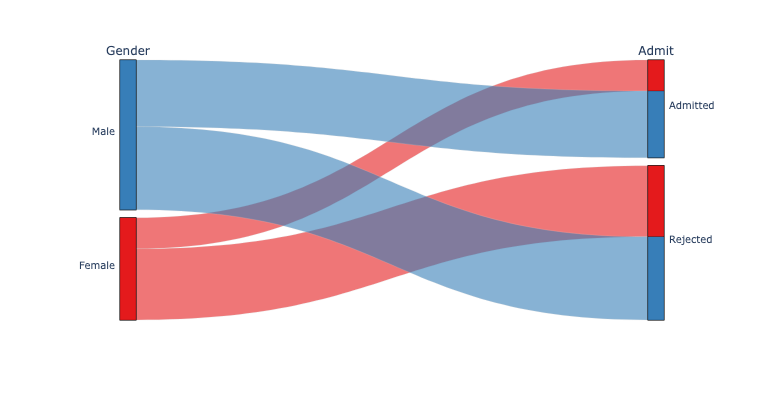

In [530]:
fig = px.parallel_categories(
    ucb_people, 
    dimensions=['Gender', 'Admit'], 
    color=ucb_people.Gender.cat.codes,
    color_continuous_scale=plotly_cmap[:len(ucb_people.Gender.unique())],
    width=600, height=400,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

From this diagram, we see that, overall, women are admitted at a lower rate than men.

Now let's add the department in the middle.

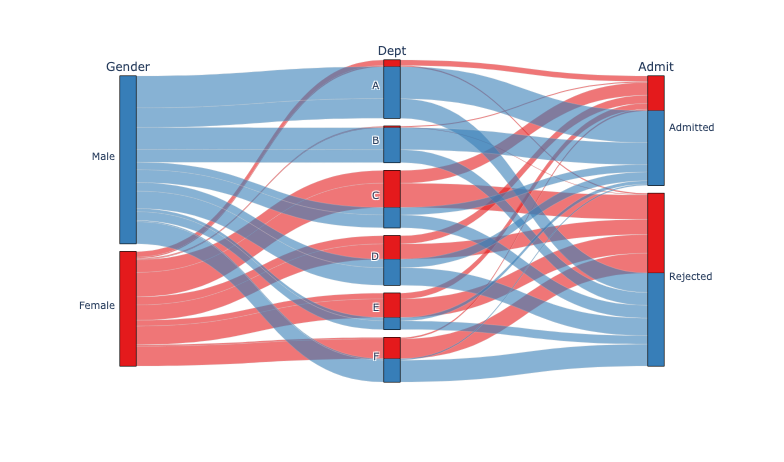

In [531]:
fig = px.parallel_categories(
    ucb_people,
    dimensions=['Gender', 'Dept', 'Admit'], 
    color=ucb_people.Gender.cat.codes,
    color_continuous_scale=plotly_cmap[:len(ucb_people.Gender.unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

In this diagram, we see the following:

- Most women applied to departments $C$ through $F$, which reject most applicants of either gender.

- Most men applied to $A$ and $B$, which admit most applicants.

So, one reason for lower admission rates for women may have been that they tended to apply to harder departments.

Let's check the rates directly.

In [507]:
X = ucb.pivot_table(index='Dept', columns=['Gender', 'Admit'], values='Freq', aggfunc='sum')
F = X['Female'].Admitted / X['Female'].sum(axis = 1)
M = X['Male'].Admitted / X['Male'].sum(axis = 1)
pd.concat([M,F], keys=['Male','Female'], axis = 1).style.background_gradient(axis=1)

,Male,Female
Dept,,
A,0.620606,0.824074
B,0.630357,0.680000
C,0.369231,0.340641
D,0.330935,0.349333
E,0.277487,0.239186
F,0.058981,0.070381


Within four of the six departments, women were admitted at a higher rate than men.

This reversal is called **Simpson's paradox**.

The two-axis diagram suggests one story, and the three-axis diagram tells the opposite one.

Which axes we include is a claim about what matters.

### Hair and eye color

Let look at another table with counts instead of individuals for observations.

In [534]:
hec_data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/HairEyeColor.csv"
hec = pd.read_csv(hec_data_url).drop('rownames', axis=1)
hec.head()

,Hair,Eye,Sex,Freq
0,Black,Brown,Male,32
1,Brown,Brown,Male,53
2,Red,Brown,Male,10
3,Blond,Brown,Male,3
4,Black,Blue,Male,11


We convert columns and expand rows.

In [535]:
hec_group_cols = ['Hair', 'Eye', 'Sex']
hec[hec_group_cols] = hec[hec_group_cols].astype('category')
hec_people = hec.loc[hec.index.repeat(hec['Freq'])].reset_index(drop=True).drop('Freq', axis=1)
hec_people.sample(5)

,Hair,Eye,Sex
156,Brown,Blue,Male
14,Black,Brown,Male
385,Red,Brown,Female
241,Blond,Hazel,Male
114,Brown,Blue,Male


Let's also create our own color scheme, to match hair color.

In [536]:
hair_colors = {c:c.lower() for c in hec.Hair.cat.categories}
hair_colors

{'Black': 'black', 'Blond': 'blond', 'Brown': 'brown', 'Red': 'red'}

In [537]:
hair_colors['Blond'] = 'gold' 
hair_colors['Brown'] = 'chocolate'
hair_colors['Red']   = 'orange'

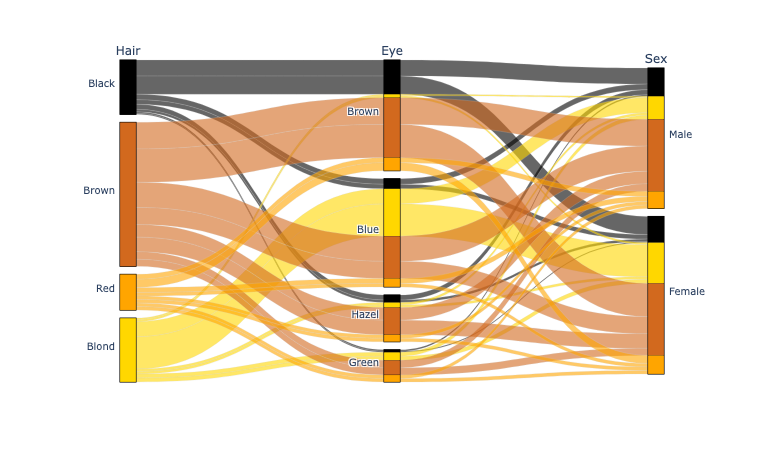

In [538]:
fig = px.parallel_categories(
    hec_people, 
    dimensions=hec_group_cols, 
    color=hec_people['Hair'].cat.codes,
    color_continuous_scale=list(hair_colors.values()),
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Most blond-haired people have blue eyes, and most blue-eyed people have blond or brown hair.

What about green eyes?

## Wide data

Finally, we can also visualize wide data with an alluvial, **where vertical axes represent subsets of the data** grouped according some sequential variable, such as year.

Alluvials like this can show **how people or things change behavior over time**.

Here's an example from a flu vaccine dataset.

### Changing minds about the flu vaccine

The `vaccinations` shows the results of three surveys, each associated with a year.

Each survey tracks a profile, called a `subject`, and associates it with a response to a question about how often they take a vaccine.
 
The `freq` variable shows the number of respondents with that profile.

In [540]:
vacc_data_url = "https://virginia.box.com/shared/static/qmqjw749ybstm365e3p2sw2lvv09qqeb.csv"
vacc = pd.read_csv(vacc_data_url)
vacc.head()

,survey,freq,subject,response,start_date,end_date
0,ms153_NSA,48,1,Always,2010-09-22,2010-10-25
1,ms153_NSA,9,2,Always,2010-09-22,2010-10-25
2,ms153_NSA,66,3,Always,2010-09-22,2010-10-25
3,ms153_NSA,1,4,Always,2010-09-22,2010-10-25
4,ms153_NSA,11,5,Always,2010-09-22,2010-10-25


You can see here that `subject` is repreated $3$ times, one for each survey, and always has the same `freq` value but differing `response` values.

In [514]:
vacc.query("subject == 3")

,survey,freq,subject,response,start_date,end_date
2,ms153_NSA,66,3,Always,2010-09-22,2010-10-25
41,ms432_NSA,66,3,Missing,2015-06-04,2015-10-05
80,ms460_NSA,66,3,Always,2016-09-27,2016-10-25


Let's create a grouping column out of the date and use it to widen the dataframe.

We want to have subjects as rows, years as columns, and responses as values.

In [542]:
vacc['year'] = vacc['start_date'].str[:4]
vacc.head()

,survey,freq,subject,response,start_date,end_date,year
0,ms153_NSA,48,1,Always,2010-09-22,2010-10-25,2010
1,ms153_NSA,9,2,Always,2010-09-22,2010-10-25,2010
2,ms153_NSA,66,3,Always,2010-09-22,2010-10-25,2010
3,ms153_NSA,1,4,Always,2010-09-22,2010-10-25,2010
4,ms153_NSA,11,5,Always,2010-09-22,2010-10-25,2010


We widen the table and add a column for frequency.

In [543]:
vacc_wide = (
    vacc
    .pivot(index='subject', columns='year', values='response')
    .join(vacc[['subject','freq']].drop_duplicates().set_index('subject'))
)
vacc_wide

,2010,2015,2016,freq
subject,,,,
1,Always,Always,Always,48
2,Always,Always,Sometimes,9
3,Always,Missing,Always,66
4,Always,Missing,Never,1
5,Always,Missing,Sometimes,11
6,Always,Never,Always,1
7,Always,Sometimes,Always,5
8,Always,Sometimes,Sometimes,4
9,Missing,Always,Always,24


Since this is a count table, we need to expand it.

In [545]:
vacc_wide_exp = (
    vacc_wide
    .loc[vacc_wide.index.repeat(vacc_wide['freq'])]
    .reset_index(drop=True)
    .drop('freq', axis=1)
)
vacc_wide_exp.index.name = 'subject_exp'
vacc_wide_exp = vacc_wide_exp.astype('category')
vacc_wide_exp

,2010,2015,2016
subject_exp,,,
0,Always,Always,Always
1,Always,Always,Always
2,Always,Always,Always
3,Always,Always,Always
4,Always,Always,Always
...,...,...,...
948,Sometimes,Sometimes,Sometimes
949,Sometimes,Sometimes,Sometimes
950,Sometimes,Sometimes,Sometimes


And here we visualize it:

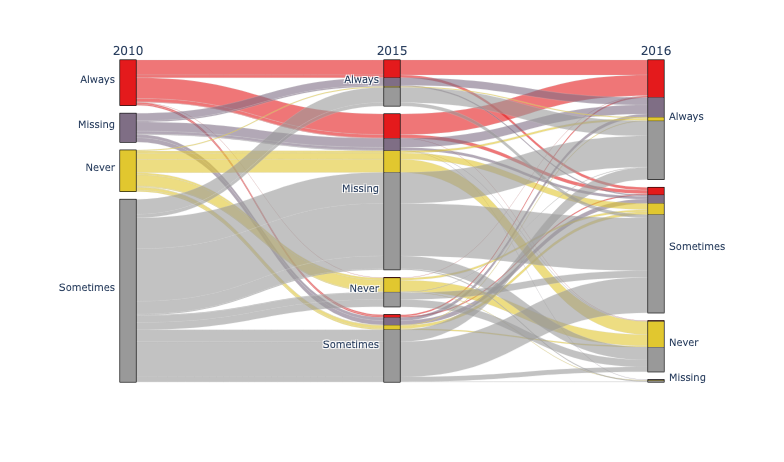

In [546]:
fig = px.parallel_categories(
    vacc_wide_exp, 
    dimensions=vacc_wide_exp.columns,
    color=vacc_wide_exp['2010'].cat.codes,
    color_continuous_scale=plotly_cmap,
    width=800, height=450
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Notice how many respondents are *Missing* in 2015: more than half of them.

Yet almost all of them answer again in 2016.

Drag the 2015 axis to the end so that 2010 sits next to 2016.

Now we can see that most people who said *Always* in 2010 still said *Always* six years later.

The *Sometimes* group is the least stable.

### Voters switching parties

Here's another table to show changing behavior over time.

The `polpan` table follows Polish voters through three parliamentary elections.

It is **wide** already, with a count column `n`.

In [547]:
polpan_data_url = "https://virginia.box.com/shared/static/3lqirf6hzd702y24hoyne6spb5iyn08q.csv"
polpan = pd.read_csv(polpan_data_url)
polpan.head()

,party2007,party2011,party2015,n
0,not voted,not voted,not voted,73
1,not voted,not voted,PO,16
2,not voted,not voted,PiS,19
3,not voted,not voted,PSL,3
4,not voted,not voted,Other,9


Here we clean up the column names and convert the groups to categories.

In [548]:
polpan.columns = [col.replace("party", "") for col in polpan.columns]
group_cols = ['2007', '2011', '2015']
polpan[group_cols] = polpan[group_cols].astype('category')

Next, we expand the dataframe.

In [549]:
polpan_exp = polpan.loc[polpan.index.repeat(polpan['n'])].reset_index(drop=True).drop('n', axis=1)
polpan_exp

,2007,2011,2015
0,not voted,not voted,not voted
1,not voted,not voted,not voted
2,not voted,not voted,not voted
3,not voted,not voted,not voted
4,not voted,not voted,not voted
...,...,...,...
681,Left,Left,Left
682,Other,not voted,PiS
683,Other,not voted,PiS
684,Other,not voted,PiS


In [550]:
# parties = polpan[group_cols].stack().unique()
# parties

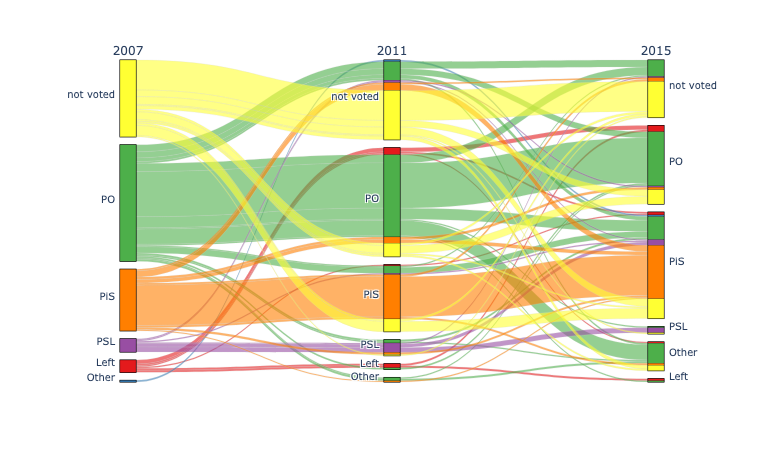

In [551]:
fig = px.parallel_categories(
    polpan_exp, 
    dimensions=polpan_exp.columns, 
    color=polpan_exp['2007'].cat.codes,
    color_continuous_scale=plotly_cmap[:len(polpan_exp['2007'].unique())],
    width=800, height=450
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

How many $2007$ `PO` voters stayed with `PO` in $2015$?

Where did the rest go?

## When alluvial diagrams mislead

### Flows imply that the same individuals are being tracked

The `alluvial` package also includes UNHCR refugee counts for ten countries from 2003 to 2013.

In [552]:
refugees_data_url = "https://virginia.box.com/shared/static/i8unovg5od58s2qlkln25i456d7kpabj.csv"
refugees = pd.read_csv(refugees_data_url)
refugees.head()

,country,year,refugees
0,Afghanistan,2003,2136043
1,Burundi,2003,531637
2,Congo DRC,2003,453465
3,Iraq,2003,368580
4,Myanmar,2003,151384


This table has one row per country per year.

It counts different people each year, though, so nothing connects a refugee in 2003 to a refugee in 2004.

If we pivot `year` onto the columns, there is nothing to put in the cells but a number, and `parallel_categories` has no categories to connect.

In [553]:
refugees_wide = refugees.pivot(index='country', columns='year', values='refugees')
refugees_wide

year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
country,,,,,,,,,,,
Afghanistan,2136043,2084109,2166149,2107519,1909911,1817913,1905804,3054709,2664436,2586034,2556507
Burundi,531637,485454,438706,396541,375715,281592,94239,84064,101288,73362,72652
Congo DRC,453465,461042,430929,401914,370386,367995,455852,476693,491481,509082,499320
Iraq,368580,311905,262299,1450905,2279245,1873519,1785212,1683575,1428308,746181,401384
Myanmar,151384,161013,164864,202826,191256,184347,206650,215644,214594,215338,222053
Palestine,350568,350617,349673,334142,335219,333990,95177,93299,94121,94820,96044
Somalia,402336,389304,395553,464252,455356,559153,678308,770148,1075148,1136713,1121772
Sudan,606242,730647,693632,686311,523032,397013,348500,379067,491013,558195,636400
Syria,20819,21440,16401,12338,13671,15186,17884,18428,19900,728603,2457255


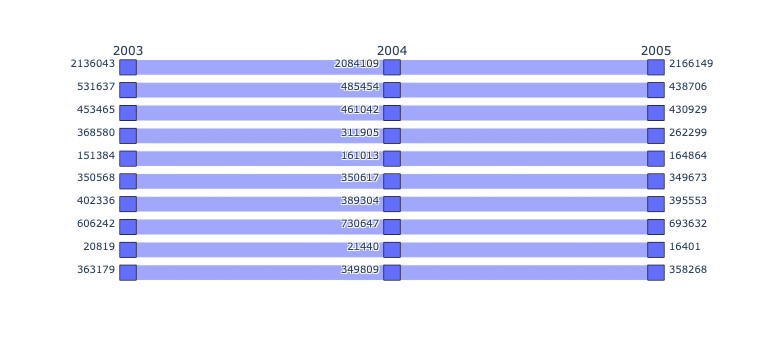

In [554]:
px.parallel_categories(
    refugees_wide.reset_index(),
    dimensions=[2003,2004,2005]
)

The right picture here is a time series, with years on the x axis and one series per country.

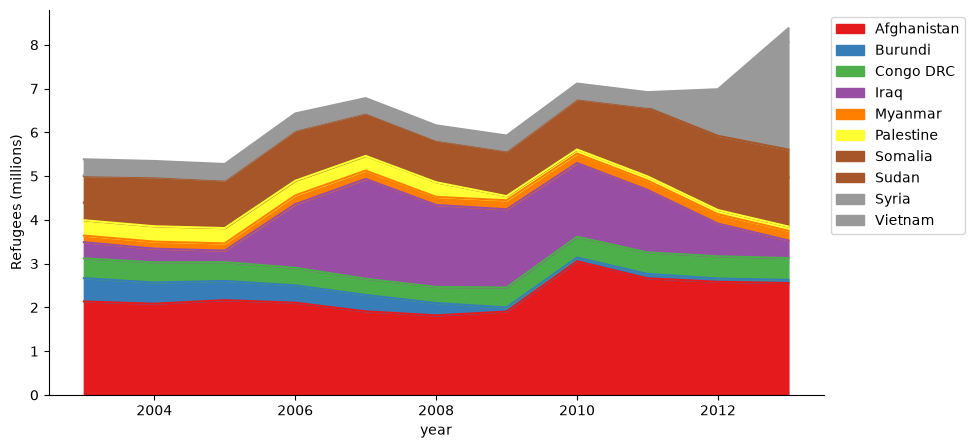

In [555]:
(refugees
    .pivot(index='year', columns='country', values='refugees')
    .div(1e6)
    .plot
    .area(figsize=(10, 5), cmap='Set1', ylabel='Refugees (millions)')
)
plt.legend(bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

```{caution}
An alluvial diagram promises that the flows follow the same observations from axis to axis.

If your data don't link observations across axes, the flows are invented.
```

### Axis order changes the story

The flows connect only *neighboring* axes.

In the Berkeley example, putting `Dept` between `Gender` and `Admit` revealed something that `Gender → Admit` hid.

Try dragging the axes in any of the diagrams above to see how the picture changes.

### Too many categories

Every new category multiplies the number of possible flows.

Bin numeric variables, and lump rare categories into *Other*, before plotting.

### Color can follow only one axis

We colored each diagram by a single variable.

Everything else must be read from the positions of the flows, which is harder.

Choose the coloring variable that carries your main question.

## Summary

- An alluvial diagram shows how observations divide across a sequence of categorical axes.
- `px.parallel_categories` needs a wide table with one row per observation and one column per axis.
- Tidy (long) repeated measures need a `pivot`; counted tables need `index.repeat` with `counts`.
- Color by one variable, fix the order of categories, and keep the number of categories small.
- Only draw flows when the same observations really do pass through every axis.